In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("SCD.csv")

In [3]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [4]:
df.isnull().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [5]:
df.shape

(100, 24)

In [6]:
#selection of features and target variables
x=df[["Stock levels","Lead times","Order quantities"]]
y=df[["Costs"]]

In [7]:
#splitting the data into training and testing
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [8]:
#fitting the linear regression model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
lr_model=model.fit(x_train,y_train)

In [9]:
#predictions the target variable for the test set
y_pred=lr_model.predict(x_test)
print("Predicted values:",y_pred)

Predicted values: [[483.52376068]
 [577.42349273]
 [426.13390344]
 [453.03407136]
 [563.54274804]
 [566.74616806]
 [431.0715431 ]
 [476.01191572]
 [540.64789799]
 [529.8838118 ]
 [456.08447928]
 [547.11430091]
 [593.18980438]
 [591.01439026]
 [604.1532124 ]
 [426.88949494]
 [354.55601143]
 [602.9338315 ]
 [667.19724887]
 [499.05503829]]


In [12]:
#model evaluation
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [14]:
#printing the evaluation metrics
print("mean squared error",mse)
print("mean absolute error",mae)
print("r.squared",r2_score)
print("slope:",lr_model.coef_[0])
print("intercept:",lr_model.intercept_)

mean squared error 84085.3342419636
mean absolute error 252.47556852088275
r.squared <function r2_score at 0x00000185E411F100>
slope: [0.07476413 6.69738978 1.80605648]
intercept: [305.28434236]


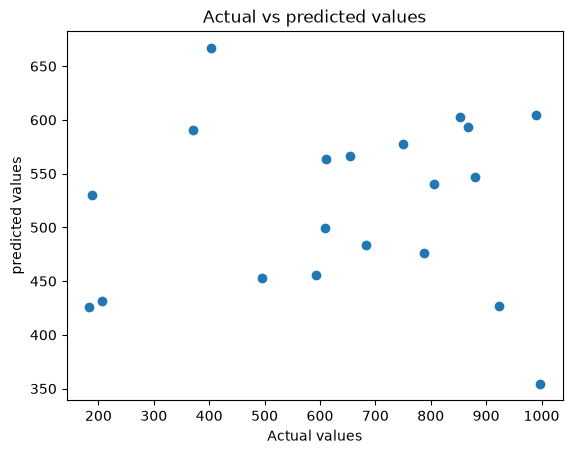

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel('Actual values')
plt.ylabel('predicted values')
plt.title('Actual vs predicted values')
plt.show()

In [30]:
#new data for prediction
new_data=[[60,5,85]]
new_pred=lr_model.predict(new_data)
print("predicted cost for new data:",new_pred)

predicted cost for new data: [[496.77193927]]


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
